# Session 25: Neural Networks Fundamentals and Types
### Duration: ~2-2.5 Hours

---

## Session Goal
In Session 24, we trained a very small neural network on the Iris dataset.

In this session, we slow down and understand:

- What a neural network is
- What neurons, weights, biases, and layers mean
- How a neural network learns
- Why activation functions are needed
- What different types of neural networks are used for
- How to choose the right neural network type for a problem

This is a concept-first session with small Python demonstrations.

## Big Message
A neural network is not one single model. It is a family of models.

Different neural network architectures are designed for different kinds of data:

```text
Tabular data -> Feedforward Neural Network / MLP
Images -> Convolutional Neural Network / CNN
Text and sequences -> RNN, LSTM, GRU, Transformer
Anomaly detection -> Autoencoder
Generation -> GAN, Diffusion model, Transformer
```

---
## 1. Recap: What We Did in Session 24

In Session 24, we used the Iris dataset.

The input data had 4 measurements:

```text
sepal length
sepal width
petal length
petal width
```

The output had 3 classes:

```text
setosa
versicolor
virginica
```

Our neural network was a basic **MLP**, which means **Multi-Layer Perceptron**.

Simple structure:

```text
4 input values -> hidden layer -> 3 output classes
```

Today we explain what is happening inside this structure.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

RANDOM_STATE = 42
OUTPUT_DIR = Path('session25_artifacts')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Environment ready.')

Environment ready.


---
## 2. What Is a Neural Network?

A neural network is a machine learning model made of connected mathematical units called **neurons**.

Each neuron receives input values, gives each input a weight, adds a bias, and produces an output.

A simple neuron can be written as:

```text
z = w1*x1 + w2*x2 + w3*x3 + ... + b
```

Where:

- `x` means input value
- `w` means weight
- `b` means bias
- `z` means weighted sum

Then the neuron applies an **activation function**:

```text
a = activation(z)
```

The activation function decides what signal should move to the next layer.

---
## 3. Neuron Example With Simple Numbers

Imagine a model predicting whether a student will pass.

Inputs:

```text
study_hours = 6
attendance = 80
previous_score = 70
```

A neuron gives each input an importance using weights:

```text
study_hours weight = 0.5
attendance weight = 0.03
previous_score weight = 0.04
bias = -5
```

The neuron calculates one score.

In [2]:
study_hours = 6
attendance = 80
previous_score = 70

w_study = 0.5
w_attendance = 0.03
w_previous = 0.04
bias = -5

z = (w_study * study_hours) + (w_attendance * attendance) + (w_previous * previous_score) + bias

print('Weighted sum:', round(z, 3))

Weighted sum: 3.2


This weighted sum is not yet a final probability. We usually pass it through an activation function.

For binary classification, a common activation idea is **sigmoid**, which converts any number into a value between 0 and 1.

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

probability = sigmoid(z)
print('Pass probability:', round(probability, 3))

Pass probability: 0.961


---
## 4. Layers in a Neural Network

A neural network usually has three parts:

### Input Layer
The input features from the dataset.

Example:

```text
Iris input layer = 4 measurements
```

### Hidden Layer
The hidden layer learns intermediate patterns.

Example:

```text
A hidden neuron may learn a pattern like: large petal length + large petal width
```

### Output Layer
The final prediction.

Examples:

```text
Binary classification -> 1 output neuron
Multi-class classification -> one output per class
Regression -> 1 numeric output
```

---
## 5. Activation Functions

Without activation functions, a neural network would mostly behave like a simpler linear model.

Activation functions help neural networks learn non-linear patterns.

We will look at four common activation functions:

- Linear
- Sigmoid
- ReLU
- Softmax

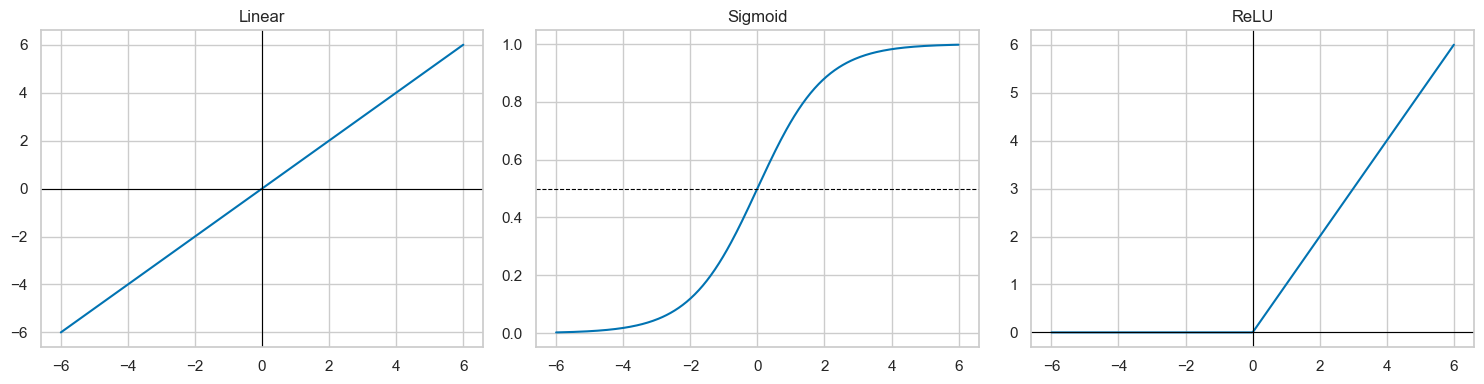

Raw class scores: [2.  1.  0.1]
Softmax probabilities: [0.659 0.242 0.099]
Sum of probabilities: 1.0


In [4]:
x = np.linspace(-6, 6, 300)

linear = x
sigmoid_values = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)

def softmax(values):
    exp_values = np.exp(values - np.max(values))
    return exp_values / exp_values.sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, linear)
axes[0].set_title('Linear')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].plot(x, sigmoid_values)
axes[1].set_title('Sigmoid')
axes[1].axhline(0.5, color='black', linewidth=0.8, linestyle='--')

axes[2].plot(x, relu)
axes[2].set_title('ReLU')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

example_scores = np.array([2.0, 1.0, 0.1])
print('Raw class scores:', example_scores)
print('Softmax probabilities:', softmax(example_scores).round(3))
print('Sum of probabilities:', softmax(example_scores).sum().round(3))

### When Do We Use Them?

| Activation | Common Use |
|---|---|
| Linear | Regression output |
| Sigmoid | Binary classification output |
| ReLU | Hidden layers |
| Softmax | Multi-class classification output |

In beginner neural networks, ReLU is a common default for hidden layers.

---
## 6. How a Neural Network Learns

A neural network learns through repeated improvement.

The basic process:

```text
1. Start with random weights
2. Make predictions
3. Calculate loss
4. Send the error backward
5. Update weights
6. Repeat many times
```

Important terms:

| Term | Simple Meaning |
|---|---|
| Forward pass | Data moves from input to output |
| Loss | Mistake score |
| Backpropagation | Method for sending error backward |
| Optimizer | Algorithm that updates weights |
| Learning rate | Size of each update step |
| Epoch | One full pass through the training data |
| Batch size | Number of samples used before one update |

For this course, students do not need heavy gradient math yet. The main idea is enough.

---
## 7. Tiny Learning Demo: Different Learning Rates

Learning rate controls how big each update step is.

Very small learning rate:

```text
Learning can be slow
```

Very large learning rate:

```text
Learning can become unstable
```

We will train a few small neural networks and compare their loss curves.

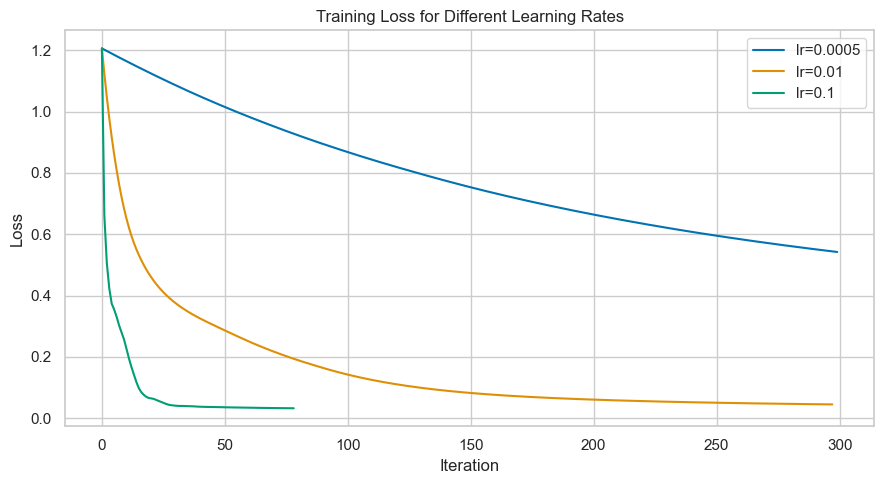

,learning_rate,iterations,final_loss,test_accuracy
0,0.0005,300,0.5421,0.8158
1,0.0100,298,0.0449,0.9737
2,0.1000,79,0.0323,0.9211


In [5]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

learning_rates = [0.0005, 0.01, 0.1]
loss_results = {}
accuracy_results = []

for lr in learning_rates:
    model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', MLPClassifier(
            hidden_layer_sizes=(8,),
            activation='relu',
            solver='adam',
            learning_rate_init=lr,
            max_iter=300,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train, y_train)
    classifier = model.named_steps['classifier']
    loss_results[f'lr={lr}'] = classifier.loss_curve_
    accuracy_results.append({
        'learning_rate': lr,
        'iterations': classifier.n_iter_,
        'final_loss': classifier.loss_,
        'test_accuracy': accuracy_score(y_test, model.predict(X_test)),
    })

plt.figure(figsize=(9, 5))
for label, curve in loss_results.items():
    plt.plot(curve, label=label)
plt.title('Training Loss for Different Learning Rates')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(accuracy_results).round(4)

---
## 8. Type 1: Feedforward Neural Network / MLP

This is the simplest neural network type.

Other names:

```text
Feedforward Neural Network
Dense Neural Network
Multi-Layer Perceptron / MLP
```

Structure:

```text
Input -> Dense Layer -> Dense Layer -> Output
```

Used for:

- Simple tabular classification
- Simple tabular regression
- Beginner deep learning examples

Examples:

- Iris classification
- Customer churn prediction
- House price prediction

This is the type we used in Session 24.

In [6]:
mlp_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(8,),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,
        max_iter=500,
        random_state=RANDOM_STATE,
    )),
])

mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

print('MLP test accuracy:', round(accuracy_score(y_test, mlp_pred), 4))
print('\nClassification report:')
print(classification_report(y_test, mlp_pred, target_names=iris.target_names))

MLP test accuracy: 0.9737

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



---
## 9. Type 2: Convolutional Neural Network / CNN

CNNs are designed mainly for image data.

Images have spatial structure:

```text
Nearby pixels are related to each other
```

CNNs learn visual patterns step by step:

```text
Edges -> corners -> shapes -> objects
```

Used for:

- Image classification
- Object detection
- Face recognition
- Medical image analysis
- Self-driving car vision

Example:

```text
Input image -> CNN layers -> cat/dog prediction
```

We will not code CNNs today. CNNs deserve their own session.

---
## 10. Type 3: Recurrent Neural Network / RNN

RNNs are designed for sequence data.

Sequence data has order:

```text
word 1 -> word 2 -> word 3
```

or

```text
time step 1 -> time step 2 -> time step 3
```

RNNs try to remember previous information while reading the sequence.

Used for:

- Text processing
- Time series forecasting
- Speech data
- Sequence prediction

Example:

```text
The movie was very ___
```

An RNN uses previous words to help predict the next word.

---
## 11. Type 4: LSTM and GRU

Basic RNNs can struggle with long sequences.

They may forget information from earlier steps.

LSTM and GRU are improved RNN-style architectures.

### LSTM
Long Short-Term Memory network.

### GRU
Gated Recurrent Unit.

Both are designed to remember useful sequence information for longer.

Used for:

- Time series forecasting
- Speech recognition
- Older NLP systems
- Sequence classification

Simple idea:

```text
RNN = basic sequence memory
LSTM/GRU = better sequence memory
```

---
## 12. Type 5: Autoencoder

An autoencoder learns to copy its input to its output.

That sounds strange, but the middle part is compressed.

Structure:

```text
Input -> Encoder -> Compressed Representation -> Decoder -> Reconstructed Input
```

Used for:

- Dimensionality reduction
- Noise removal
- Anomaly detection
- Feature learning

Example:

```text
If an autoencoder learns normal machine behavior, it may reconstruct normal data well.
If a strange abnormal signal appears, reconstruction error may be high.
```

---
## 13. Type 6: GAN

GAN means **Generative Adversarial Network**.

A GAN has two neural networks:

```text
Generator -> creates fake data
Discriminator -> tries to detect fake data
```

They compete with each other.

Used for:

- Image generation
- Style transfer
- Creative AI
- Data generation experiments

Simple story:

```text
The generator tries to create realistic images.
The discriminator tries to catch fake images.
Both improve through competition.
```

GANs are powerful but harder to train, so they are not beginner models.

---
## 14. Type 7: Transformer

Transformers are the architecture behind many modern AI systems.

They are especially powerful for text, but are also used for images, audio, and code.

Important idea:

```text
Attention
```

Attention helps the model focus on the most important parts of the input.

Used for:

- Translation
- Summarization
- Chatbots
- Search
- Code generation
- Large language models
- Vision transformers

Examples:

```text
BERT
GPT-style models
Modern translation systems
```

For now, students only need to know:

> Transformers are neural networks that use attention to process information very effectively.

---
## 15. Choosing the Right Neural Network Type

| Data Type / Problem | Common Neural Network Type |
|---|---|
| Small tabular data | Classical ML or MLP |
| Large tabular data | MLP, tree-based models, or hybrid approaches |
| Images | CNN, Vision Transformer |
| Text | Transformer, sometimes RNN/LSTM |
| Time series | RNN, LSTM, GRU, Transformer |
| Audio | CNN, RNN, Transformer |
| Anomaly detection | Autoencoder |
| Image generation | GAN, Diffusion model |
| Chatbots and LLMs | Transformer |

Important lesson:

> Do not use deep learning just because it sounds advanced. Choose the model based on the data and the problem.

In [7]:
network_table = pd.DataFrame({
    'network_type': [
        'MLP / Feedforward',
        'CNN',
        'RNN',
        'LSTM / GRU',
        'Autoencoder',
        'GAN',
        'Transformer',
    ],
    'best_for': [
        'Tabular data and basic classification/regression',
        'Images and computer vision',
        'Simple sequence data',
        'Longer sequence and time series data',
        'Compression, denoising, anomaly detection',
        'Generating realistic synthetic data',
        'Text, language, code, multimodal AI',
    ],
    'beginner_example': [
        'Iris classification',
        'Fashion MNIST image classification',
        'Next value in a sequence',
        'Temperature forecasting',
        'Detect unusual transactions',
        'Generate simple images',
        'Text classification or summarization',
    ],
})

network_table

,network_type,best_for,beginner_example
0,MLP / Feedforward,Tabular data and basic classification/regression,Iris classification
1,CNN,Images and computer vision,Fashion MNIST image classification
2,RNN,Simple sequence data,Next value in a sequence
3,LSTM / GRU,Longer sequence and time series data,Temperature forecasting
4,Autoencoder,"Compression, denoising, anomaly detection",Detect unusual transactions
5,GAN,Generating realistic synthetic data,Generate simple images
6,Transformer,"Text, language, code, multimodal AI",Text classification or summarization


---
## 16. Architecture Experiment: Hidden Layers

A neural network architecture is the design of the network.

For an MLP, we can change:

- Number of hidden layers
- Number of neurons in each hidden layer
- Activation function
- Learning rate
- Number of iterations

Let us compare a few simple MLP architectures on Iris.

In [8]:
architecture_configs = {
    'Tiny: 2 neurons': (2,),
    'Small: 8 neurons': (8,),
    'Medium: 16 neurons': (16,),
    'Two layers: 16 then 8': (16, 8),
}

architecture_results = []
trained_models = {}

for name, hidden_layers in architecture_configs.items():
    model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation='relu',
            solver='adam',
            learning_rate_init=0.01,
            max_iter=500,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    classifier = model.named_steps['classifier']
    trained_models[name] = model
    architecture_results.append({
        'architecture': name,
        'hidden_layer_sizes': hidden_layers,
        'test_accuracy': accuracy_score(y_test, preds),
        'final_loss': classifier.loss_,
        'iterations': classifier.n_iter_,
    })

architecture_df = pd.DataFrame(architecture_results)
architecture_df.round(4)

,architecture,hidden_layer_sizes,test_accuracy,final_loss,iterations
0,Tiny: 2 neurons,"(2,)",0.9737,0.1822,500
1,Small: 8 neurons,"(8,)",0.9737,0.0449,298
2,Medium: 16 neurons,"(16,)",0.9211,0.0392,191
3,Two layers: 16 then 8,"(16, 8)",0.9474,0.0351,127


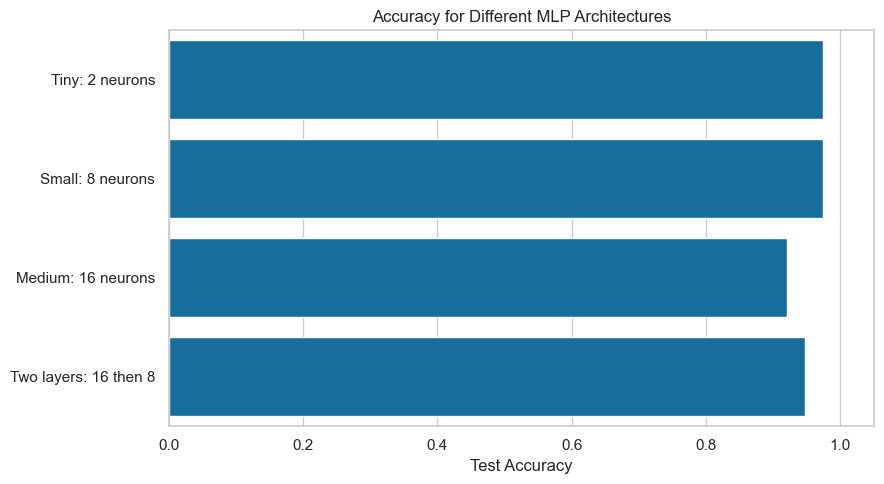

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(data=architecture_df, x='test_accuracy', y='architecture')
plt.xlim(0, 1.05)
plt.title('Accuracy for Different MLP Architectures')
plt.xlabel('Test Accuracy')
plt.ylabel('')
plt.tight_layout()
plt.show()

---
## 17. Compare With Classical ML Again

This is an important habit.

Whenever we try deep learning, we should still ask:

```text
Can a simpler model solve this well enough?
```

For small tabular datasets, Logistic Regression can be very strong.

In [10]:
logistic_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logistic_model.fit(X_train, y_train)
logistic_accuracy = accuracy_score(y_test, logistic_model.predict(X_test))

best_architecture_row = architecture_df.sort_values('test_accuracy', ascending=False).iloc[0]

comparison_df = pd.DataFrame({
    'model': ['Logistic Regression', f"Best MLP: {best_architecture_row['architecture']}"],
    'test_accuracy': [logistic_accuracy, best_architecture_row['test_accuracy']],
})

comparison_df.round(4)

,model,test_accuracy
0,Logistic Regression,0.9211
1,Best MLP: Tiny: 2 neurons,0.9737


---
## 18. Save Session Artifacts

We save the tables and one trained model so students can see that neural network models can also be reused later.

In [11]:
best_model_name = best_architecture_row['architecture']
best_model = trained_models[best_model_name]

model_path = OUTPUT_DIR / 'best_intro_mlp_model.joblib'
architecture_path = OUTPUT_DIR / 'mlp_architecture_experiment.csv'
network_table_path = OUTPUT_DIR / 'neural_network_types_table.csv'
comparison_path = OUTPUT_DIR / 'classical_vs_mlp_comparison.csv'

dump(best_model, model_path)
architecture_df.to_csv(architecture_path, index=False)
network_table.to_csv(network_table_path, index=False)
comparison_df.to_csv(comparison_path, index=False)

print('Saved model:', model_path)
print('Saved architecture experiment:', architecture_path)
print('Saved neural network types table:', network_table_path)
print('Saved model comparison:', comparison_path)

Saved model: session25_artifacts\best_intro_mlp_model.joblib
Saved architecture experiment: session25_artifacts\mlp_architecture_experiment.csv
Saved neural network types table: session25_artifacts\neural_network_types_table.csv
Saved model comparison: session25_artifacts\classical_vs_mlp_comparison.csv


---
## 19. Class Discussion Questions

Use these questions to check understanding:

1. What is the difference between a neuron and a layer?
2. What are weights and biases?
3. Why do we need activation functions?
4. What does loss measure?
5. What is the purpose of an optimizer?
6. Why is an MLP called feedforward?
7. Why are CNNs better suited for images than basic MLPs?
8. Why are RNNs, LSTMs, and GRUs connected to sequence data?
9. What does an autoencoder try to do?
10. What is the big idea behind Transformers?
11. Should we always use deep learning for every ML problem?

---

## Final Summary

A neural network is a model made of connected neurons arranged in layers.

The core building blocks are:

```text
Inputs -> weights -> bias -> activation -> output
```

The learning process is:

```text
Prediction -> loss -> backpropagation -> optimizer update -> repeat
```

Different neural network types are designed for different data:

```text
MLP -> tabular data
CNN -> images
RNN/LSTM/GRU -> sequences
Autoencoder -> compression and anomaly detection
GAN -> generation
Transformer -> modern text, code, and multimodal AI
```

Most important takeaway:

> Neural networks are powerful, but model choice should always depend on the problem, data type, dataset size, and business goal.

Next recommended session:

```text
Session 26: Image Classification with Fashion MNIST
```